In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

# helper function to concat random split results

In [14]:
from pathlib import Path



def create_concat_df_rand(exp_patterns, legible_exp_names, base_subdir='v2_no_onehot'):
    """
    Like create_concat_df, but exp_patterns are glob patterns that match
    multiple seed directories, e.g. 'test_v4_rand_s*_geo_k40_ratio80_droplowest5'.
    Adds a 'seed' column extracted from the directory name.
    """
    BASE = Path('/nlp/scr/salilg/showcase_property_tax/results/geo_pooling')
    dfs = []
    for pattern, legible_name in zip(exp_patterns, legible_exp_names):
        seed_dirs = sorted((BASE / base_subdir).glob(pattern))
        if not seed_dirs:
            print(f"Warning: no directories matched '{pattern}'")
            continue
        for seed_dir in seed_dirs:
            # if 's4' in str(seed_dir):
            #     continue
            chunks = []
            for i in range(4):
                p = seed_dir / f'chunk_{i}' / 'results.csv'
                if p.exists():
                    chunks.append(pd.read_csv(p))
            if not chunks:
                continue
            df = pd.concat(chunks, ignore_index=True)
            df = df[df['status'] == 'success']
            df['seed'] = seed_dir.name          # e.g. 'test_v4_rand_s2_geo_k40_ratio80_droplowest5'
            df['experiment'] = legible_name

            # Deduplicate: keep first successful entry per (fips, model).
            # The checkpoint system can accumulate duplicates from re-runs.
            n_before = len(df)
            df = df.drop_duplicates(subset=['fips', 'model'], keep='first')
            n_dropped = n_before - len(df)
            if n_dropped > 0:
                print(f"  Deduplicated {seed_dir.name}: dropped {n_dropped} duplicate rows")

            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# helper functions to plot

In [15]:
def format_model_name(model_name):
    if model_name == 'tabpfn':
        return 'TabPFN'
    elif model_name == 'xgboost':
        return 'XGBoost'
    elif model_name == 'tabpfn_global_finetuned':
        return 'TabPFN (finetuned globally)'
    elif model_name == 'tabpfn_finetuned':
        return 'TabPFN (finetuned per county)'
    else:
        return model_name

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_line_by_train_size(
    df,
    experiment_names,
    metric='mape',
    train_size_col='own_train_size',
    bucket_size=None,
    ylim=None,
    median=False,
    n_se=2,
    title_addition=""
):
    """
    Plot mean ± SE for many experiments.
    Colors = models (tabpfn, xgboost, ...)
    Line styles = experiments (pooling type)
    """

    df_all = df

    # ----------------------
    # 2. Optional binning
    # ----------------------
    if bucket_size is not None:
        bucket_col = '_train_bucket'
        df_all[bucket_col] = (df_all[train_size_col] // bucket_size) * bucket_size
        x_col = bucket_col
    else:
        x_col = train_size_col

    # ----------------------
    # 3. Aggregate statistics
    # ----------------------
    stats = (
        df_all
        .groupby([x_col, 'model', 'experiment'])[metric]
        .agg(['mean', 'std', 'median', 'count'])
        .reset_index()
    )
    stats['se'] = stats['std'] / np.sqrt(stats['count'])

    # ----------------------
    # 4. Colors = model
    # ----------------------
    models = sorted(stats['model'].unique())
    palette = sns.color_palette("tab10", n_colors=len(models))
    model_color = {m: palette[i] for i, m in enumerate(models)}

    # ----------------------
    # 5. Line styles = experiment (pooling type)
    # ----------------------
    _linestyles = ['-', '--', ':', '-.']
    experiments = sorted(stats['experiment'].unique())
    experiment_linestyle = {exp: _linestyles[i % len(_linestyles)] for i, exp in enumerate(experiments)}

    # Marker style stays per-model for extra clarity
    model_marker = {
        'tabpfn': 'o',
        'xgboost': 'x',
        'tabpfn_global_finetuned': 's',
        'tabpfn_finetuned': '^',
    }

    # ----------------------
    # 6. Plot
    # ----------------------
    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    exp_to_offset = {exp: (i - len(experiments)/2) * 2.2 for i, exp in enumerate(experiments)}

    for (exp, model), mdf in stats.groupby(['experiment', 'model']):
        mdf = mdf.sort_values(x_col)
        x_vals = mdf[x_col] + exp_to_offset[exp]

        if median:
            ax.plot(
                x_vals,
                mdf['median'],
                color=model_color[model],
                linestyle=experiment_linestyle.get(exp, '-'),
                label=f'{format_model_name(model)} ({exp})'
            )
        else:
            ax.errorbar(
                x_vals,
                mdf['mean'],
                yerr=n_se * mdf['se'],
                fmt=model_marker.get(model, 'o'),
                linestyle=experiment_linestyle.get(exp, '-'),
                color=model_color[model],
                capsize=3,
                linewidth=2,
                markersize=5,
                label=f'{format_model_name(model)} ({exp})'
            )

    # ----------------------
    # 7. Axes formatting
    # ----------------------
    if bucket_size is not None:
        xs = sorted(stats[x_col].unique())
        ax.set_xticks(xs)
        n_per_bucket = stats.groupby(x_col)['count'].max()
        ax.set_xticklabels([f'{x}–{x+bucket_size}\n(n={n_per_bucket[x]})' for x in xs])
        ax.set_xlabel(f'{train_size_col} (binned, width={bucket_size})')
    else:
        ax.set_xlabel(train_size_col)

    ax.set_ylabel(metric.upper())
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(f'{metric.upper()} vs Target County\'s {train_size_col}\n'
                 f'Plot shows mean ± {n_se} SE\n'
                 f'{title_addition}')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(fontsize=8, title='Model (pooling type)', handlelength=3)

    plt.tight_layout()
    plt.show()

In [17]:
def plot_diff_from_baseline(
    df,
    baseline,          # tuple of (experiment_name, model), e.g. ('nopooling_droplowest5', 'xgboost')
    metric='mape',
    train_size_col='own_train_size',
    bucket_size=None,
    ylim=None,
    n_se=2,            # 1 or 2 standard errors for error bars
    title_addition=""
):
    """
    For each (experiment, model) combo (excluding baseline), compute per-FIPS paired
    differences (baseline - other), then plot mean ± n_se*SE of those differences by train size bucket.
    Positive = baseline is worse (higher error) than other.
    """

    df_all = df.copy()

    # ----------------------
    # 1. Optional bucketing
    # ----------------------
    if bucket_size is not None:
        bucket_col = '_train_bucket'
        df_all[bucket_col] = (df_all[train_size_col] // bucket_size) * bucket_size
        x_col = bucket_col
    else:
        x_col = train_size_col

    # ----------------------
    # 2. Extract baseline series (one row per fips)
    # ----------------------
    baseline_exp, baseline_model = baseline

    if 'seed' not in df_all.columns:
        baseline_df = (
            df_all[
                (df_all['experiment'] == baseline_exp) &
                (df_all['model'] == baseline_model)
            ]
            [['fips', metric]]
            .rename(columns={metric: '_baseline'})
        )
    else:
        # Extract seed number (e.g., 's0', 's1', ...) from the seed string
        df_all['_seed_num'] = df_all['seed'].str.extract(r'(rand_s\d+)')

        baseline_df = (
            df_all[
                (df_all['experiment'] == baseline_exp) &
                (df_all['model'] == baseline_model)
            ]
            [['fips', '_seed_num', metric]]
            .rename(columns={metric: '_baseline'})
        )

    # ----------------------
    # 3. Compute paired diffs for every other (experiment, model)
    # ----------------------
    results = []

    for (exp, model), group in df_all.groupby(['experiment', 'model']):
        if exp == baseline_exp and model == baseline_model:
            continue
        
        if '_seed_num' in group.columns:
            merged = group.merge(baseline_df, on=['fips', '_seed_num'], how='inner')
        else:
            merged = group.merge(baseline_df, on='fips', how='inner')
            
        merged['diff'] = merged['_baseline'] - merged[metric]  # baseline - other

        agg = (
            merged
            .groupby(x_col)['diff']
            .agg(['mean', 'std', 'count'])
            .reset_index()
        )
        agg['se'] = agg['std'] / np.sqrt(agg['count'])
        agg['experiment'] = exp
        agg['model'] = model
        results.append(agg)

    stats = pd.concat(results, ignore_index=True)

    # ----------------------
    # 4. Colors = experiments, line styles = model
    # ----------------------
    experiments = sorted(stats['experiment'].unique())
    palette = sns.color_palette("tab10", n_colors=len(experiments))
    experiment_color = {exp: palette[i] for i, exp in enumerate(experiments)}

    model_linestyle = {'tabpfn': '-', 'xgboost': '--'}

    # ----------------------
    # 5. Plot
    # ----------------------
    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    exp_to_offset = {exp: (i - len(experiments) / 2) * 2.2 for i, exp in enumerate(experiments)}

    for (exp, model), mdf in stats.groupby(['experiment', 'model']):
        mdf = mdf.sort_values(x_col)
        x_vals = mdf[x_col] + exp_to_offset[exp]

        ax.errorbar(
            x_vals,
            mdf['mean'],
            yerr=n_se * mdf['se'],
            fmt='o' if model == 'tabpfn' else 'x',
            linestyle=model_linestyle.get(model, '-'),
            color=experiment_color[exp],
            capsize=3,
            linewidth=2,
            markersize=5,
            label=f'{format_model_name(model)} ({exp})'
        )

    # Reference line at 0
    ax.axhline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.5, zorder=0)

    # ----------------------
    # 6. Axes formatting
    # ----------------------
    if bucket_size is not None:
        xs = sorted(stats[x_col].unique())
        ax.set_xticks(xs)
        # ax.set_xticklabels([f'{x}–{x+bucket_size}' for x in xs])
        n_per_bucket = stats.groupby(x_col)['count'].max()
        ax.set_xticklabels([f'{x}–{x+bucket_size}\n(n={n_per_bucket[x]})' for x in xs])

        ax.set_xlabel(f'{train_size_col} (binned, width={bucket_size})')
    else:
        ax.set_xlabel(train_size_col)

    ax.set_ylabel(f'{metric.upper()} difference (baseline − other)')
    if ylim is not None:
        ax.set_ylim(ylim)

    # ci_label = '~68% CI' if n_se == 1 else '~95% CI'
    baseline_label = f'{format_model_name(baseline_model)} ({baseline_exp})'
    ax.set_title(
        f'{metric.upper()} relative to {baseline_label}\n'
        f'Positive = baseline is worse | Plot shows mean ±{n_se} SE\n'
        f'{title_addition}'
    )
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(fontsize=8, title='Model (training data)', handlelength=3)

    plt.tight_layout()
    plt.show()


# visualize experiment results

In [22]:
exp_patterns = [
    'test_v4_rand_s*_geo_k40_ratio80_droplowest5',
    'test_v4_rand_s*_geo_k40_nopooling_droplowest5',
    # 'test_v4_rand_s*_geo_k40_ratio150_droplowest5',
    # 'test_v4_rand_s*_geo_k40_ratio500_droplowest5',
]
legible_exp_names = ['Pooling ratio 80%', 'No pooling']#, 'k40_ratio150_droplowest5', 'k40_ratio500_droplowest5']

df = create_concat_df_rand(exp_patterns, legible_exp_names)

  Deduplicated test_v4_rand_s0_geo_k40_nopooling_droplowest5: dropped 518 duplicate rows
  Deduplicated test_v4_rand_s1_geo_k40_nopooling_droplowest5: dropped 516 duplicate rows
  Deduplicated test_v4_rand_s2_geo_k40_nopooling_droplowest5: dropped 517 duplicate rows
  Deduplicated test_v4_rand_s3_geo_k40_nopooling_droplowest5: dropped 516 duplicate rows
  Deduplicated test_v4_rand_s4_geo_k40_nopooling_droplowest5: dropped 518 duplicate rows


In [7]:
# df = df[df['experiment'] != 'Pooling ratio 80%']

In [21]:
df[df['model']=='tabpfn']

,fips,size_bucket,model,own_train_size,neighbor_train_size,total_train_size,test_size,n_features,fit_time,pred_time,...,mae,rmse,mape,mse,status,experiment_name,experiment_description,seed,experiment,_train_bucket
128,1011,small,tabpfn,60,48,108,15,107,6.714320,1.211119,...,49726.366681,97598.917269,31.531590,9.525549e+09,success,test_v4_rand_s0_geo_k40_ratio80_droplowest5,"Per-county geo pooling, random split seed 0, m...",test_v4_rand_s0_geo_k40_ratio80_droplowest5,Pooling ratio 80%,40
129,1013,medium,tabpfn,351,280,631,87,107,1.623370,0.704155,...,36592.563013,84463.952129,35.062223,7.134159e+09,success,test_v4_rand_s0_geo_k40_ratio80_droplowest5,"Per-county geo pooling, random split seed 0, m...",test_v4_rand_s0_geo_k40_ratio80_droplowest5,Pooling ratio 80%,320
130,1025,medium,tabpfn,203,162,365,47,107,1.138005,0.415900,...,18237.086935,26093.545260,31.730967,6.808731e+08,success,test_v4_rand_s0_geo_k40_ratio80_droplowest5,"Per-county geo pooling, random split seed 0, m...",test_v4_rand_s0_geo_k40_ratio80_droplowest5,Pooling ratio 80%,200
131,1029,medium,tabpfn,193,154,347,48,107,1.312232,0.390668,...,45114.397095,63388.868851,40.792728,4.018149e+09,success,test_v4_rand_s0_geo_k40_ratio80_droplowest5,"Per-county geo pooling, random split seed 0, m...",test_v4_rand_s0_geo_k40_ratio80_droplowest5,Pooling ratio 80%,160
132,1037,medium,tabpfn,327,261,588,81,107,1.456383,0.628072,...,95720.717782,168475.317408,40.382500,2.838393e+10,success,test_v4_rand_s0_geo_k40_ratio80_droplowest5,"Per-county geo pooling, random split seed 0, m...",test_v4_rand_s0_geo_k40_ratio80_droplowest5,Pooling ratio 80%,320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18095,56013,tiny,tabpfn,28,0,28,6,107,0.498941,0.201127,...,30719.216156,31477.582990,29.155183,9.908382e+08,success,test_v4_rand_s4_geo_k40_nopooling_droplowest5,"Per-county geo pooling, random split seed 4, m...",test_v4_rand_s4_geo_k40_nopooling_droplowest5,No pooling,0
18097,56019,medium,tabpfn,335,0,335,84,107,0.771656,1.146122,...,74373.390720,102980.996681,30.803699,1.060509e+10,success,test_v4_rand_s4_geo_k40_nopooling_droplowest5,"Per-county geo pooling, random split seed 4, m...",test_v4_rand_s4_geo_k40_nopooling_droplowest5,No pooling,320
18099,56031,medium,tabpfn,281,0,281,71,107,0.678209,0.975881,...,65328.051338,96881.818101,26.786771,9.386087e+09,success,test_v4_rand_s4_geo_k40_nopooling_droplowest5,"Per-county geo pooling, random split seed 4, m...",test_v4_rand_s4_geo_k40_nopooling_droplowest5,No pooling,280
18101,56035,medium,tabpfn,343,0,343,87,107,0.881169,1.331661,...,65899.789904,85034.645376,23.896058,7.230891e+09,success,test_v4_rand_s4_geo_k40_nopooling_droplowest5,"Per-county geo pooling, random split seed 4, m...",test_v4_rand_s4_geo_k40_nopooling_droplowest5,No pooling,320


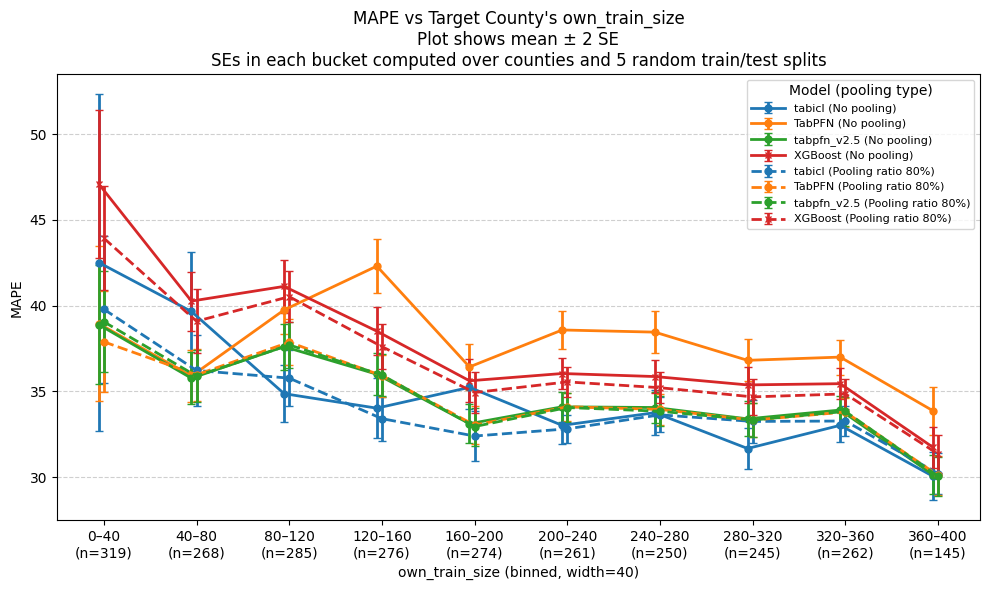

In [19]:
plot_line_by_train_size(
    df, legible_exp_names, bucket_size=40, 
    title_addition='SEs in each bucket computed over counties and 5 random train/test splits'
    )

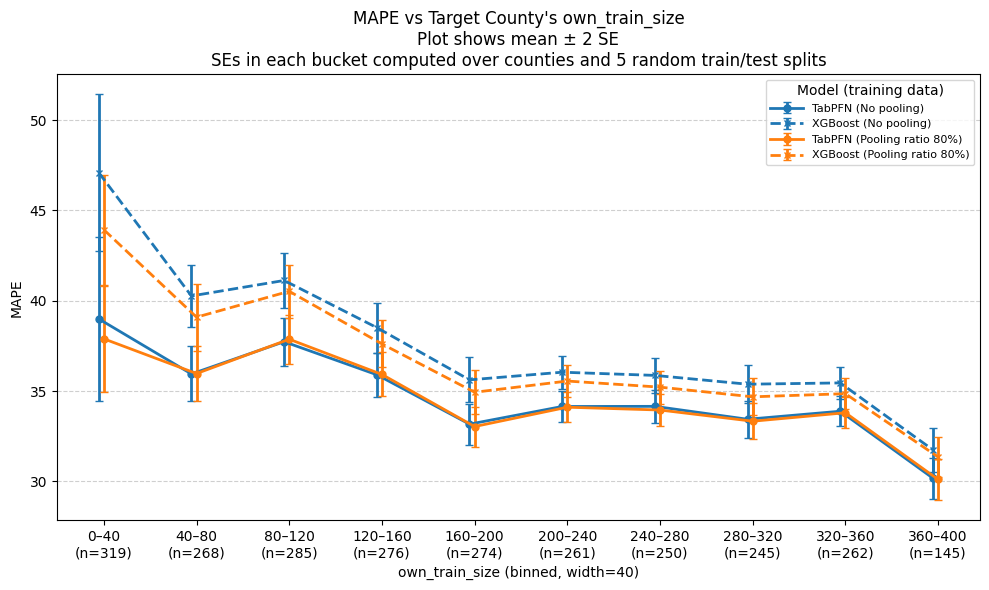

In [62]:
plot_line_by_train_size(
    df, legible_exp_names, bucket_size=40, 
    title_addition='SEs in each bucket computed over counties and 5 random train/test splits'
    )

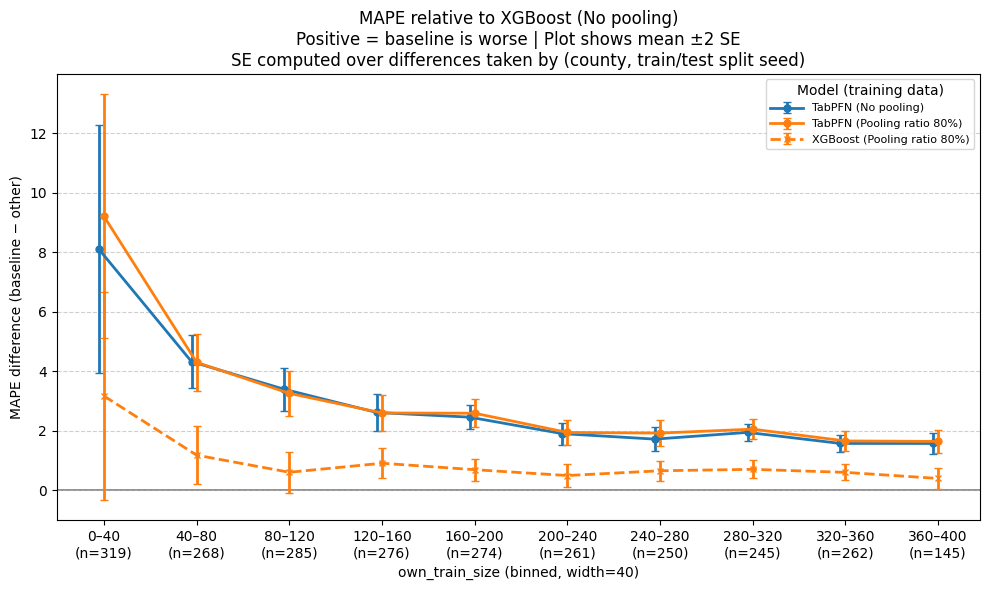

In [63]:
plot_diff_from_baseline(
    df, ('No pooling', 'xgboost'), bucket_size=40, n_se=2, 
    title_addition='SE computed over differences taken by (county, train/test split seed)'
    )